# Barotropic Vorticity Equation: Visualization Guide

This notebook demonstrates standard visualization techniques for atmospheric model output.
All data is synthetically generated so each technique can be studied in isolation.
The same code applies directly to real simulator output (e.g., Isca NetCDF loaded via xarray).

The barotropic vorticity equation (BVE) on a rotating sphere is:

$$\frac{D(\zeta + f)}{Dt} = F + D$$

where $\zeta$ is relative vorticity, $f = 2\Omega\sin\phi$ is the Coriolis parameter,
$F$ is external stirring, and $D$ is dissipation.

## Organization

| Part | Scope | Applies to |
|---|---|---|
| 1 | BVE-specific | Barotropic vorticity equation only |
| 2 | Fluid dynamics general | Any fluid system (Navier-Stokes, shallow water, etc.) |
| 3 | PDE general | Any PDE-based or learned operator model |

---
## Setup: Synthetic Data

We generate synthetic data that mimics the output of a real barotropic model.
The data generation is intentionally simple -- the focus of this notebook is on
the **visualization techniques**, not the simulation.

**Grid:** T42-resolution lat-lon grid ($64 \times 128$ points).

**Vorticity field:** Generated in 2D Fourier space with an isotropic $k^{-3}$ energy
spectrum, tapered above wavenumber 15 to produce large, coherent eddies.

**Time evolution:** Pure eastward phase shift (15 deg/snapshot). This is not a real
simulation -- it just produces plausible-looking time-varying fields so we can
demonstrate time-dependent diagnostics.

**Winds:** Derived from the streamfunction via $u = -\partial\psi/\partial y$,
$v = \partial\psi/\partial x$, added to a background zonal jet at $\pm 45^\circ$.

**Prediction field:** A Gaussian-blurred version of the true vorticity plus small noise.
This mimics the over-smoothing bias common in learned operators, used for error diagnostics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

plt.rcParams["figure.dpi"] = 100

# --- Grid ---
NLAT  = 64
NLON  = 128
NTIME = 12

lat     = np.linspace(-87.5, 87.5, NLAT)
lon     = np.linspace(0.0, 360.0 - 360.0 / NLON, NLON)
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)
LON, LAT = np.meshgrid(lon_rad, lat_rad)

EARTH_RADIUS = 6.371e6   # m
OMEGA        = 7.292e-5  # rad/s
CORIOLIS     = 2.0 * OMEGA * np.sin(LAT)

dlat    = lat_rad[1] - lat_rad[0]
dlon    = lon_rad[1] - lon_rad[0]
cos_lat = np.cos(LAT).clip(1e-6)

rng = np.random.default_rng(42)

# --- Background zonal jet (symmetric about equator) ---
JET_LAT   = np.deg2rad(45.0)
JET_WIDTH = np.deg2rad(15.0)
JET_SPEED = 25.0  # m/s

U_MEAN = JET_SPEED * (
    np.exp(-((LAT - JET_LAT) ** 2) / (2.0 * JET_WIDTH ** 2)) +
    np.exp(-((LAT + JET_LAT) ** 2) / (2.0 * JET_WIDTH ** 2))
)

# --- Broadband vorticity via 2D isotropic spectrum ---
nk = NLON // 2 + 1

def make_broadband_vorticity(seed, scale=8e-6):
    r = np.random.default_rng(seed)
    kx = np.fft.rfftfreq(NLON, d=1.0 / NLON)
    ky = np.fft.fftfreq(NLAT, d=1.0 / NLAT)
    KX, KY = np.meshgrid(kx, ky)
    K_MAG = np.sqrt(KX ** 2 + KY ** 2)
    K_MAG[0, 0] = 1.0

    amplitude = K_MAG ** (-2.0)
    amplitude[0, 0] = 0.0
    amplitude[K_MAG > 15] *= np.exp(-((K_MAG[K_MAG > 15] - 15) / 5) ** 2)

    noise = r.standard_normal((NLAT, nk)) + 1j * r.standard_normal((NLAT, nk))
    vor_hat = noise * amplitude
    vor = np.fft.irfft2(vor_hat, s=(NLAT, NLON))
    return vor * scale / (vor.std() + 1e-20)

# --- Streamfunction from vorticity: solve nabla^2 psi = zeta spectrally ---
DX = EARTH_RADIUS * dlon
DY = EARTH_RADIUS * dlat

kx_phys = np.fft.rfftfreq(NLON) * (2.0 * np.pi / DX)
ky_phys = np.fft.fftfreq(NLAT)  * (2.0 * np.pi / DY)
KX_PHYS, KY_PHYS = np.meshgrid(kx_phys, ky_phys)
K2_PHYS          = KX_PHYS ** 2 + KY_PHYS ** 2
K2_PHYS[0, 0]    = 1.0

def invert_for_psi(vor):
    vor_hat        = np.fft.rfft2(vor)
    psi_hat        = -vor_hat / K2_PHYS[:, :nk]
    psi_hat[0, 0]  = 0.0
    return np.fft.irfft2(psi_hat, s=(NLAT, NLON))

def winds_from_psi(psi):
    u = -np.gradient(psi, dlat, axis=0) / EARTH_RADIUS
    v =  np.gradient(psi, dlon, axis=1) / (EARTH_RADIUS * cos_lat)
    return u, v

# --- Time series: pure eastward phase shift ---
PHASE_SHIFT_DEG = 15.0
phase_shift_rad = np.deg2rad(PHASE_SHIFT_DEG)

VOR_0  = make_broadband_vorticity(seed=0)
PSI_0  = invert_for_psi(VOR_0)
U_PERT_0, V_0 = winds_from_psi(PSI_0)

def shift_field_east(field, shift_rad):
    field_hat = np.fft.rfft(field, axis=1)
    k         = np.arange(field_hat.shape[1])
    phase     = np.exp(1j * k * shift_rad / dlon)
    return np.fft.irfft(field_hat * phase[None, :], n=NLON, axis=1)

VOR_list = [VOR_0.copy()]
for t in range(1, NTIME):
    VOR_list.append(shift_field_east(VOR_0, t * phase_shift_rad))

VOR  = np.array(VOR_list)
PSI  = np.array([invert_for_psi(VOR[t]) for t in range(NTIME)])
U_TS = np.array([U_MEAN + winds_from_psi(PSI[t])[0] for t in range(NTIME)])
V_TS = np.array([winds_from_psi(PSI[t])[1] for t in range(NTIME)])

PSI_0  = PSI[0]
U_FULL = U_TS[0]
V_0    = V_TS[0]

# --- Synthetic prediction ---
VOR_TRUE = VOR_0.copy()
VOR_PRED = gaussian_filter(VOR_0, sigma=1.5) + 0.08 * rng.standard_normal((NLAT, NLON)) * VOR_0.std()

# --- Area weighting ---
cos_lat_2d = np.cos(LAT).clip(0)
area_norm  = cos_lat_2d.sum()

def area_mean(field):
    return (field * cos_lat_2d).sum() / area_norm

days = np.arange(NTIME) * 7
cos_weights = np.cos(lat_rad).clip(0)

print(f"Grid:            {NLAT} x {NLON}, {NTIME} snapshots")
print(f"Vorticity range: {VOR_0.min():.2e} to {VOR_0.max():.2e} s^-1")
print(f"Zonal wind:      {U_FULL.min():.1f} to {U_FULL.max():.1f} m/s")

Grid:            64 x 128, 12 snapshots
Vorticity range: -2.54e-05 to 1.71e-05 s^-1
Zonal wind:      -34.0 to 53.9 m/s


---
# Part 1: BVE-Specific Diagnostics

These visualizations are specific to barotropic vorticity equation models.
They exploit the relationship between vorticity, streamfunction, and winds
that is unique to 2D incompressible flow on a rotating sphere.

## 1.1 Vorticity Evolution (Multi-Panel Snapshots)

**What it shows.** The spatial distribution of relative vorticity $\zeta$ at multiple
time steps, arranged as a grid of maps. Each panel is one snapshot.

**Axes.** x-axis = longitude (degrees), y-axis = latitude (degrees).
Color = vorticity in $\text{s}^{-1}$ (red = cyclonic/positive, blue = anticyclonic/negative).
All panels share the same color scale so magnitudes are directly comparable.

**Time coverage.** Every snapshot in the dataset (7-day intervals, Day 0 through Day 77).

**When to use.** First look at any simulation or model output. Shows eddy structure,
propagation direction, and whether the field looks physically reasonable. For papers,
select a subset of panels at key times. For exploration, show all available snapshots.

**What to look for.**
- Coherent vortex structures (not pixel noise)
- Propagation: do features move east/west between panels?
- Growth or decay of eddies over time
- Artifacts near poles or grid boundaries

/tmp/ipykernel_32531/475899242.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


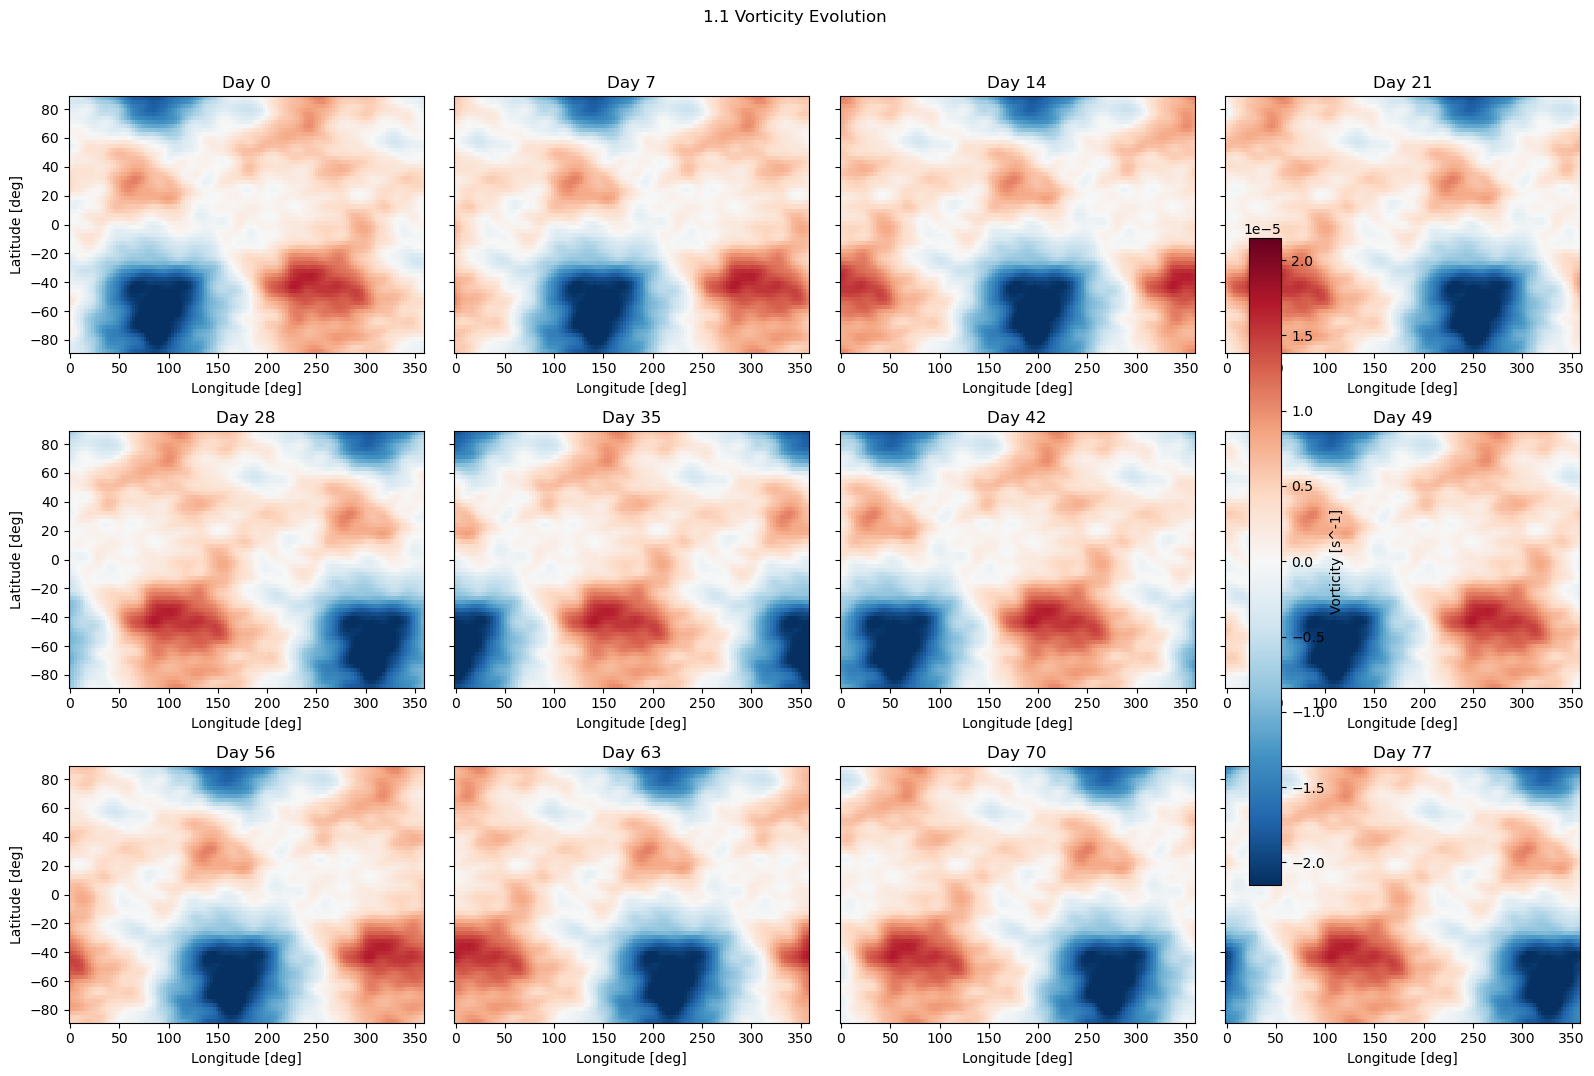

In [2]:
SNAP_INDICES = list(range(NTIME))
vlim = np.percentile(np.abs(VOR), 98)

NCOLS = 4
NROWS = int(np.ceil(len(SNAP_INDICES) / NCOLS))
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, 3.5 * NROWS), sharey=True)
for i, t in enumerate(SNAP_INDICES):
    ax = axes.flat[i]
    im = ax.pcolormesh(lon, lat, VOR[t], cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
    ax.set_title(f"Day {days[t]}")
    ax.set_xlabel("Longitude [deg]")
    if i % NCOLS == 0:
        ax.set_ylabel("Latitude [deg]")
for j in range(len(SNAP_INDICES), NROWS * NCOLS):
    axes.flat[j].set_visible(False)
fig.colorbar(im, ax=axes, label="Vorticity [s^-1]", shrink=0.8)
fig.suptitle("1.1 Vorticity Evolution", y=1.02)
plt.tight_layout()
plt.show()

## 1.2 Streamfunction

**What it shows.** The streamfunction $\psi$ at a single time step (Day 0). In 2D
incompressible flow, $\psi$ fully determines the velocity field: streamlines are
contours of $\psi$, and the flow is tangent to them everywhere.

**Axes.** x-axis = longitude (degrees), y-axis = latitude (degrees).
Color = streamfunction in $\text{m}^2\text{s}^{-1}$.
Black contour lines = streamlines (iso-$\psi$ curves).

**Time coverage.** Single snapshot (Day 0). Apply to any timestep of interest.

**When to use.** To see the large-scale circulation pattern. Useful for identifying
closed gyres, jet streams (tightly packed contours), and stagnation points.

**What to look for.**
- Closed contours = vortices or gyres
- Tightly packed contours = strong flow (jets)
- Contour spacing is proportional to wind speed

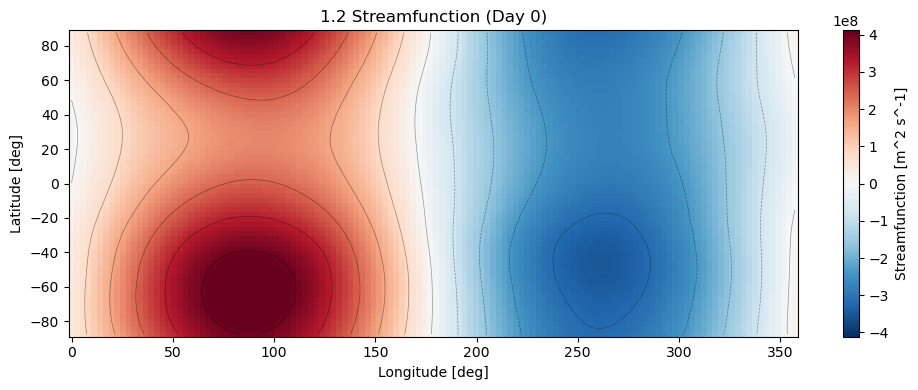

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
vlim = np.percentile(np.abs(PSI_0), 98)
im   = ax.pcolormesh(lon, lat, PSI_0, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="Streamfunction [m^2 s^-1]")
ax.contour(lon, lat, PSI_0, levels=12, colors="k", linewidths=0.5, alpha=0.4)
ax.set_title("1.2 Streamfunction (Day 0)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.show()

## 1.3 Zonal Mean Zonal Wind

**What it shows.** The zonal mean (longitude-averaged) zonal wind $[u](\phi)$ as a
function of latitude, plotted for every time step. Each colored line is one snapshot.

**Axes.** x-axis = zonal mean wind speed (m/s), y-axis = latitude (degrees).
Color of each line = simulation day (colorbar on right).

**Time coverage.** All 12 snapshots (Day 0 through Day 77), superimposed.

**When to use.** To diagnose the jet structure and its time evolution. In the BVE,
the zonal mean flow is driven by eddy momentum fluxes (the Eliassen-Palm flux).
Changes in $[u]$ reveal whether eddies are accelerating or decelerating the jet.

**What to look for.**
- Jet peaks at expected latitudes ($\pm 45^\circ$ here)
- Time evolution: are the jets accelerating, decelerating, or shifting?
- Equatorial flow: should be weak in a barotropic model
- In our synthetic data the lines overlap because a pure phase shift does not
  change the zonal mean -- in real simulations you would see spread between lines

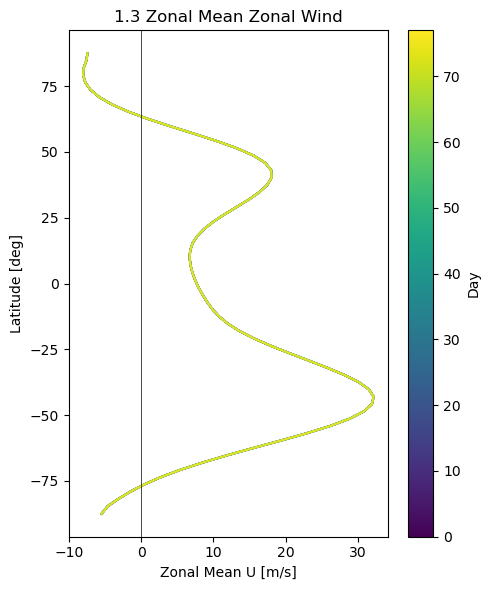

In [4]:
fig, ax = plt.subplots(figsize=(5, 6))
cmap   = plt.cm.viridis
colors = cmap(np.linspace(0, 1, NTIME))
for t in range(NTIME):
    u_zonal = U_TS[t].mean(axis=1)
    ax.plot(u_zonal, lat, color=colors[t], alpha=0.7)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, (NTIME - 1) * 7))
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Day")
ax.axvline(0, color="k", linewidth=0.5)
ax.set_xlabel("Zonal Mean U [m/s]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("1.3 Zonal Mean Zonal Wind")
plt.tight_layout()
plt.show()

## 1.4 Hovmoller Diagram

**What it shows.** A time-longitude cross section of vorticity at a fixed latitude
($\approx 45^\circ$N, the jet latitude). This is a standard technique for visualizing
wave propagation without animation.

**Axes.** x-axis = longitude (degrees), y-axis = simulation day.
Color = vorticity in $\text{s}^{-1}$.

**Time coverage.** All snapshots (Day 0 through Day 77).

**When to use.** To identify wave propagation direction and speed. Diagonal bands
sloping to the right = eastward propagation; to the left = westward. The slope
gives the phase speed. Also useful for identifying stationary waves (vertical bands)
or wave breaking (bands that deform or merge).

**What to look for.**
- Diagonal bands: slope = propagation speed and direction
- Band spacing: wavelength of the dominant wave
- Disruptions: wave breaking, blocking events
- In our synthetic data, the 15 deg/week phase shift produces clear rightward-sloping bands

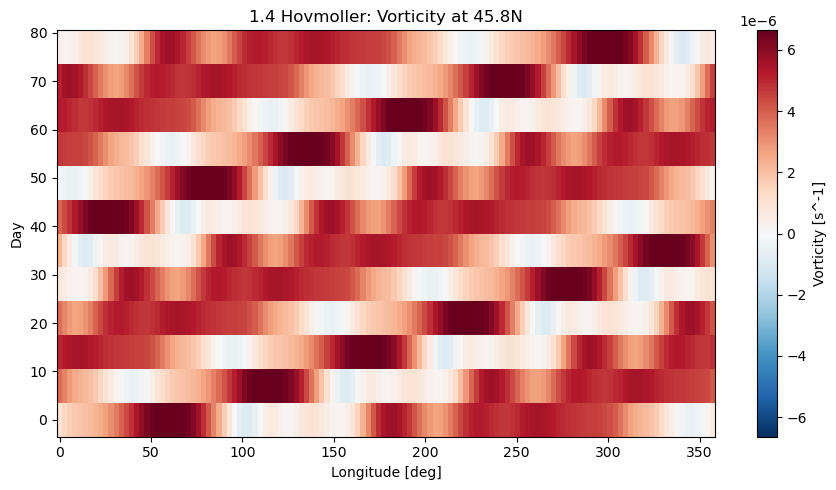

In [5]:
HOVMOLLER_LAT_IDX = np.argmin(np.abs(lat - 45.0))
VOR_AT_LAT = VOR[:, HOVMOLLER_LAT_IDX, :]

fig, ax = plt.subplots(figsize=(9, 5))
vlim = np.percentile(np.abs(VOR_AT_LAT), 98)
im   = ax.pcolormesh(lon, days, VOR_AT_LAT, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="Vorticity [s^-1]")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Day")
ax.set_title(f"1.4 Hovmoller: Vorticity at {lat[HOVMOLLER_LAT_IDX]:.1f}N")
plt.tight_layout()
plt.show()

## 1.5 Enstrophy Conservation

**What it shows.** The area-weighted global enstrophy
$\mathcal{E} = \langle \frac{1}{2} \zeta^2 \rangle$ as a function of time,
normalized by its initial value. Enstrophy is a quadratic invariant of the
inviscid BVE -- it should be exactly conserved.

**Axes.** x-axis = simulation day, y-axis = enstrophy ratio ($\mathcal{E}(t) / \mathcal{E}(0)$).
Dashed line = perfect conservation (ratio = 1.0).

**Time coverage.** All snapshots.

**When to use.** As a sanity check on any barotropic simulation or learned model.
Enstrophy drift indicates numerical dissipation (decrease) or instability (increase).
A well-tuned simulation should keep drift below ~1% over the integration period.

**What to look for.**
- Flat line at 1.0 = perfect conservation (our synthetic data, since phase shift preserves all moments)
- Downward drift = numerical dissipation (common with explicit diffusion or coarse grids)
- Upward drift = aliasing instability or energy injection
- Sudden jumps = numerical blow-up

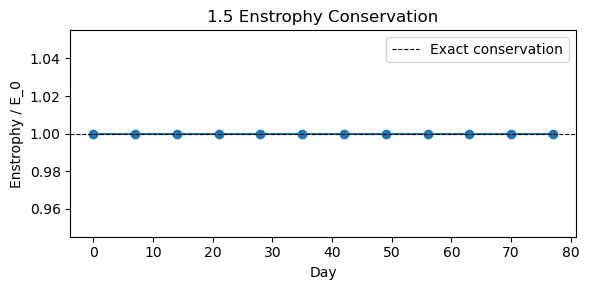

In [6]:
enstrophy = np.array([area_mean(0.5 * VOR[t] ** 2) for t in range(NTIME)])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, enstrophy / enstrophy[0], marker="o")
ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8, label="Exact conservation")
ax.set_xlabel("Day")
ax.set_ylabel("Enstrophy / E_0")
ax.set_title("1.5 Enstrophy Conservation")
ax.legend()
plt.tight_layout()
plt.show()

---
# Part 2: Fluid Dynamics General

These techniques apply to any fluid system with a velocity field --
Navier-Stokes, shallow water, ocean models, etc.

## 2.1 Wind / Velocity Quiver Plot

**What it shows.** The velocity field as arrows overlaid on a vorticity color map.
Arrow direction = wind direction, arrow length = wind speed.

**Axes.** x-axis = longitude (degrees), y-axis = latitude (degrees).
Background color = vorticity (same scale as 1.1).
Arrows are in units of degrees/day so their length is physically meaningful on the
lat-lon axes. Every 4th grid point is plotted to avoid clutter.

**Time coverage.** Single snapshot (Day 0). Apply to any timestep.

**Latitude range.** Clipped to $\pm 70^\circ$ because the $1/\cos\phi$ factor in the
longitude-to-meters conversion diverges at the poles, producing artificially long arrows.

**When to use.** To see how the flow relates to the vorticity or pressure field.
Useful for verifying that winds are geostrophically balanced (flow along contours,
not across them), identifying convergence/divergence zones, and checking for
unphysical features.

**What to look for.**
- Arrows circulating around vorticity centers (cyclonic = counterclockwise in NH)
- Jet regions: strong, aligned arrows
- Cross-contour flow: indicates ageostrophic motion or data problems

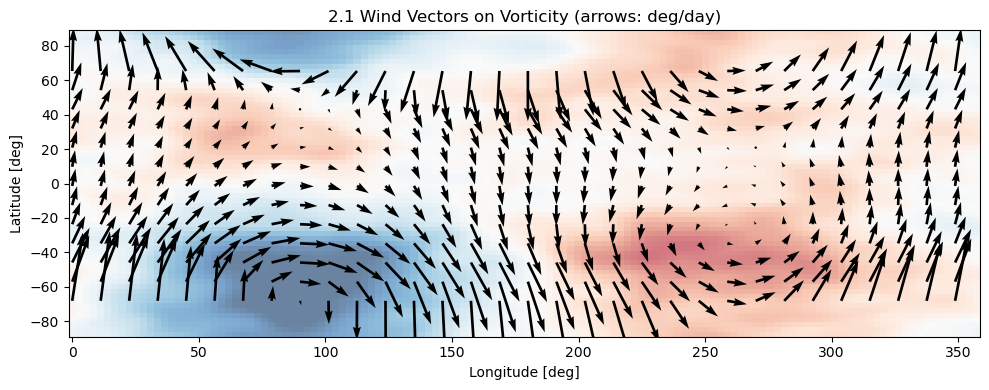

In [7]:
DEG_PER_M = 180.0 / (np.pi * EARTH_RADIUS)
SECS_PER_DAY = 86400.0

U_DEG = U_FULL * DEG_PER_M / cos_lat * SECS_PER_DAY
V_DEG = V_0    * DEG_PER_M             * SECS_PER_DAY

LAT_CLIP = 70.0
lat_mask = np.abs(lat) <= LAT_CLIP
lat_q    = lat[lat_mask]
SKIP = 4

fig, ax = plt.subplots(figsize=(10, 4))
vlim = np.percentile(np.abs(VOR_0), 98)
ax.pcolormesh(lon, lat, VOR_0, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto", alpha=0.6)
ax.quiver(
    lon[::SKIP], lat_q[::SKIP],
    U_DEG[lat_mask, :][::SKIP, ::SKIP], V_DEG[lat_mask, :][::SKIP, ::SKIP],
)
ax.set_title("2.1 Wind Vectors on Vorticity (arrows: deg/day)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.show()

## 2.2 Kinetic Energy Spectrum

**What it shows.** The area-weighted zonal kinetic energy spectrum $E(k)$ as a function
of zonal wavenumber $k$, on log-log axes. A dashed reference line shows the theoretical
$k^{-3}$ slope expected for 2D geostrophic turbulence (Charney, 1971).

**Axes.** x-axis = zonal wavenumber $k$ (dimensionless integer), y-axis = kinetic energy
per wavenumber (arbitrary units, proportional to $\text{m}^2\text{s}^{-2}$). Both log scale.

**Time coverage.** Single snapshot (Day 0). For real data, consider averaging over
multiple snapshots to reduce noise in the spectrum.

**When to use.** To diagnose whether a simulation or model reproduces the correct
energy cascade. The slope tells you about the dynamics:
- $k^{-3}$: enstrophy cascade (2D turbulence, stratified atmosphere)
- $k^{-5/3}$: inverse energy cascade (2D turbulence at large scales)
- Steeper than $k^{-3}$: excessive dissipation or over-smoothing
- Flatter than $k^{-3}$: energy injection or aliasing

**What to look for.**
- Does the spectrum follow the reference slope over a range of wavenumbers?
- Sharp drop-off at high $k$: spectral taper or dissipation cutoff
- Pile-up at highest $k$: aliasing or insufficient resolution

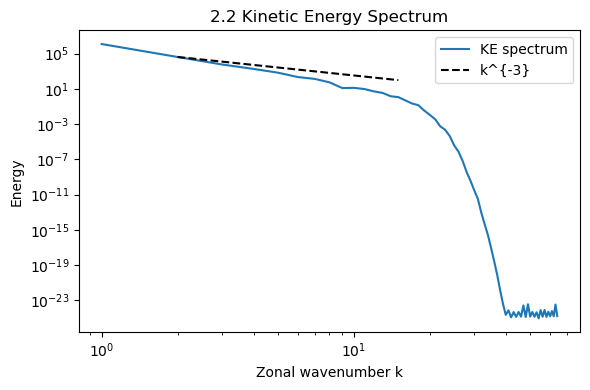

In [8]:
def zonal_energy_spectrum(u, weights):
    u_hat = np.fft.rfft(u, axis=1)
    power = (np.abs(u_hat) ** 2) * weights[:, None]
    return power.sum(axis=0) / weights.sum()

E_k = zonal_energy_spectrum(U_FULL, cos_weights)
k   = np.arange(len(E_k))
k[0] = 1

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(k[1:], E_k[1:], label="KE spectrum")
k_ref = np.array([2, 15])
ax.loglog(k_ref, E_k[2] * (k_ref / 2.0) ** (-3), "k--", label="k^{-3}")
ax.set_xlabel("Zonal wavenumber k")
ax.set_ylabel("Energy")
ax.set_title("2.2 Kinetic Energy Spectrum")
ax.legend()
plt.tight_layout()
plt.show()

## 2.3 Kinetic Energy Conservation

**What it shows.** The area-weighted global kinetic energy
$KE = \langle \frac{1}{2} u^2 \rangle$ as a function of time, normalized by its
initial value. Kinetic energy is conserved in the inviscid BVE.

**Axes.** x-axis = simulation day, y-axis = KE ratio ($KE(t) / KE(0)$).
Dashed line = perfect conservation.

**Time coverage.** All snapshots.

**When to use.** Same purpose as enstrophy conservation (1.5), but for kinetic energy.
Together, KE and enstrophy conservation provide complementary diagnostics: KE is
dominated by large scales while enstrophy is dominated by small scales. If KE drifts
but enstrophy doesn't (or vice versa), it tells you which scales are problematic.

**What to look for.**
- Same as 1.5. In real simulations, some KE loss is expected from explicit dissipation.

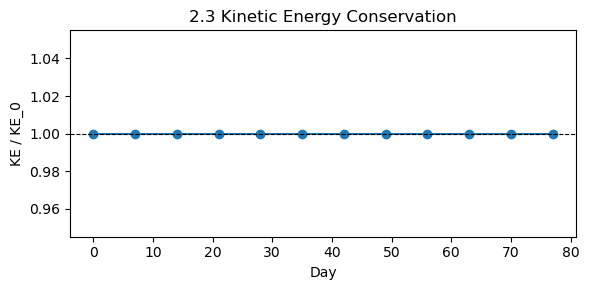

In [9]:
energy = np.array([area_mean(0.5 * U_TS[t] ** 2) for t in range(NTIME)])

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(days, energy / energy[0], marker="o")
ax.axhline(1.0, color="k", linestyle="--", linewidth=0.8)
ax.set_xlabel("Day")
ax.set_ylabel("KE / KE_0")
ax.set_title("2.3 Kinetic Energy Conservation")
plt.tight_layout()
plt.show()

---
# Part 3: PDE General

These techniques apply to any model that solves a PDE or approximates one --
including neural operators, PINNs, and traditional numerical methods. They
compare a model prediction against a reference (ground truth) solution.

## 3.1 Error Maps

**What it shows.** Three spatial maps of the error between a predicted field and the
ground truth, each highlighting a different aspect:

- **Absolute error** $|\hat{\zeta} - \zeta|$: Where is the error largest?
  Colormap: white (zero) to dark red (large). Use this to find spatial regions
  where the model struggles.

- **Signed error** $\hat{\zeta} - \zeta$: Is the model over-predicting or under-predicting?
  Colormap: blue (negative = under-prediction) to red (positive = over-prediction).
  Reveals systematic biases.

- **Relative error** $|\hat{\zeta} - \zeta| / |\zeta|$: How large is the error
  compared to the local signal? High relative error in low-amplitude regions may
  be acceptable; high relative error in strong-signal regions is a problem.

**Axes.** x-axis = longitude, y-axis = latitude. Color = error value.

**Time coverage.** Single snapshot (Day 0 prediction vs. Day 0 truth).

**When to use.** After any model evaluation. Always look at spatial error maps before
relying on scalar metrics like RMSE -- a model with low RMSE might still have
large localized errors that matter for downstream analysis.

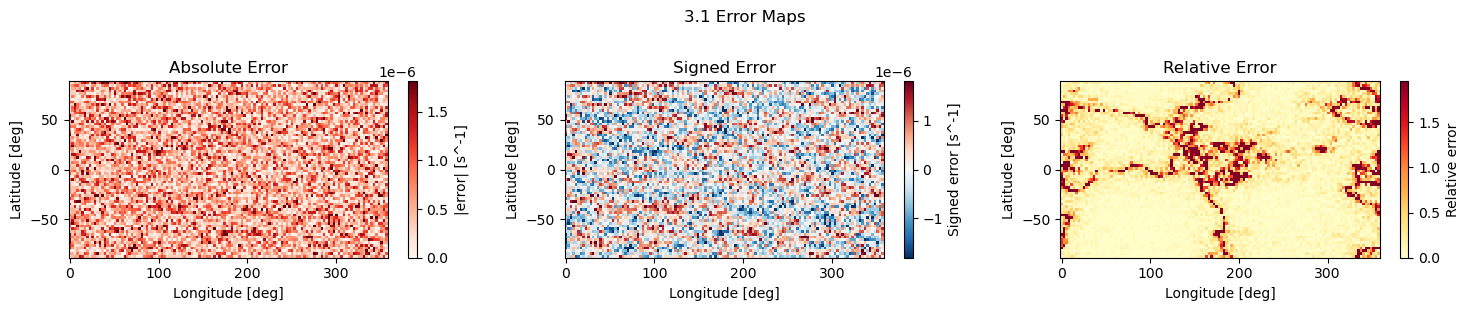

In [10]:
abs_error    = np.abs(VOR_PRED - VOR_TRUE)
signed_error = VOR_PRED - VOR_TRUE
rel_error    = abs_error / (np.abs(VOR_TRUE) + 1e-10 * VOR_TRUE.std())

fig, axes = plt.subplots(1, 3, figsize=(15, 3))

vlim = np.percentile(abs_error, 98)
im0  = axes[0].pcolormesh(lon, lat, abs_error, cmap="Reds", vmin=0, vmax=vlim, shading="auto")
fig.colorbar(im0, ax=axes[0], label="|error| [s^-1]")
axes[0].set_title("Absolute Error")

vlim = np.percentile(np.abs(signed_error), 98)
im1  = axes[1].pcolormesh(lon, lat, signed_error, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im1, ax=axes[1], label="Signed error [s^-1]")
axes[1].set_title("Signed Error")

vlim = np.percentile(rel_error, 95)
im2  = axes[2].pcolormesh(lon, lat, rel_error, cmap="YlOrRd", vmin=0, vmax=vlim, shading="auto")
fig.colorbar(im2, ax=axes[2], label="Relative error")
axes[2].set_title("Relative Error")

for ax in axes:
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")

plt.suptitle("3.1 Error Maps", y=1.02)
plt.tight_layout()
plt.show()

## 3.2 Power Spectrum Comparison

**What it shows.** Two panels comparing the spectral content of the predicted and
true fields:

- **Left: Power spectra.** The zonal power spectrum of both fields on log-log axes.
  Shows whether the prediction captures the correct energy distribution across scales.

- **Right: Spectral ratio.** $P_{\text{pred}}(k) / P_{\text{true}}(k)$ as a function
  of wavenumber. Ratio = 1 means perfect agreement at that scale. Ratio < 1 means
  the prediction is missing energy (over-smoothed). Ratio > 1 means excess energy
  (noisy or aliased).

**Axes.** x-axis = zonal wavenumber (log scale). Left y-axis = power (log scale).
Right y-axis = ratio (linear, 0 to 2).

**Time coverage.** Single snapshot comparison. Only plotted up to wavenumber 20 where
both fields have meaningful signal.

**When to use.** Essential for evaluating learned operators. A model can have low
pixel-wise RMSE but systematically smooth out small-scale features -- this only
shows up in the spectrum. The Gaussian blur prediction here demonstrates exactly
this failure mode: the ratio drops below 1 at higher wavenumbers.

**What to look for.**
- Prediction spectrum below true at high $k$: model is over-smoothing
- Prediction spectrum above true at high $k$: model is adding spurious noise
- Ratio near 1 across all $k$: spectrally accurate prediction

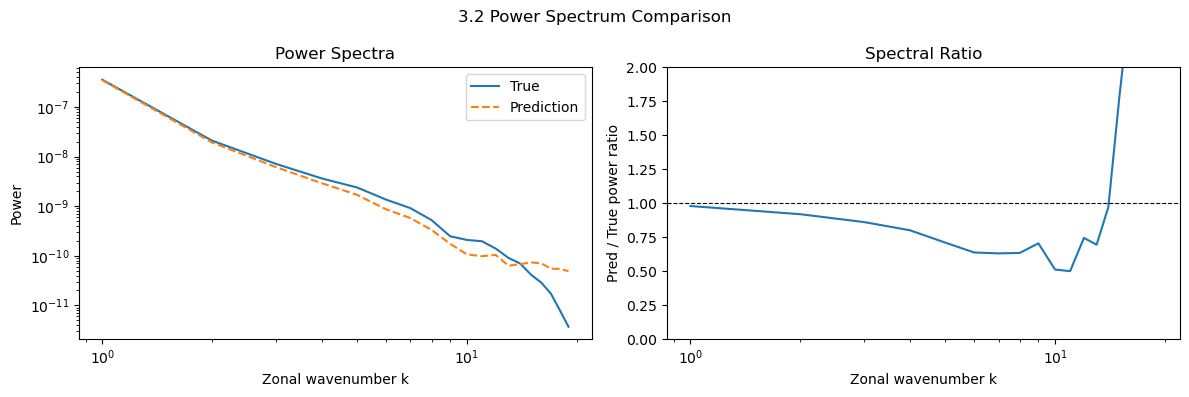

In [11]:
def power_spectrum(field, weights):
    f_hat = np.fft.rfft(field, axis=1)
    power = (np.abs(f_hat) ** 2) * weights[:, None]
    return power.sum(axis=0) / weights.sum()

P_true = power_spectrum(VOR_TRUE, cos_weights)
P_pred = power_spectrum(VOR_PRED, cos_weights)
k_ps   = np.arange(len(P_true))
k_ps[0] = 1

K_MAX_COMPARE = 20

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(k_ps[1:K_MAX_COMPARE], P_true[1:K_MAX_COMPARE], label="True")
axes[0].loglog(k_ps[1:K_MAX_COMPARE], P_pred[1:K_MAX_COMPARE], label="Prediction", linestyle="--")
axes[0].set_xlabel("Zonal wavenumber k")
axes[0].set_ylabel("Power")
axes[0].set_title("Power Spectra")
axes[0].legend()

ratio = P_pred[1:K_MAX_COMPARE] / (P_true[1:K_MAX_COMPARE] + 1e-40)
axes[1].semilogx(k_ps[1:K_MAX_COMPARE], ratio)
axes[1].axhline(1.0, color="k", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Zonal wavenumber k")
axes[1].set_ylabel("Pred / True power ratio")
axes[1].set_title("Spectral Ratio")
axes[1].set_ylim(0, 2)

plt.suptitle("3.2 Power Spectrum Comparison")
plt.tight_layout()
plt.show()

## 3.3 PDE Residual Map

**What it shows.** The residual of the governing PDE, evaluated from the model output.
For the BVE: $R = \frac{\partial\zeta}{\partial t} + \mathbf{u} \cdot \nabla\zeta$.
If the model output satisfies the PDE exactly, $R = 0$ everywhere. Non-zero residual
reveals where the model violates the governing physics.

**Axes.** x-axis = longitude, y-axis = latitude.
Color = residual in $\text{s}^{-2}$ (red = positive, blue = negative).

**Time coverage.** Computed between Day 0 and Day 7 (first two snapshots). The time
derivative is estimated as a finite difference: $(\zeta_1 - \zeta_0) / \Delta t$.
The advection term uses Day 0 winds and vorticity gradients.

**When to use.** Especially useful for physics-informed models (PINNs, neural operators
trained with PDE constraints). Even for data-driven models, the PDE residual reveals
whether the prediction is physically consistent, not just statistically accurate.

**What to look for.**
- Small, spatially uniform residual = model satisfies the PDE well
- Large residual concentrated in specific regions = physics violations there
  (e.g., near boundaries, steep gradients, or fronts)
- Residual pattern correlated with the flow structure = systematic bias

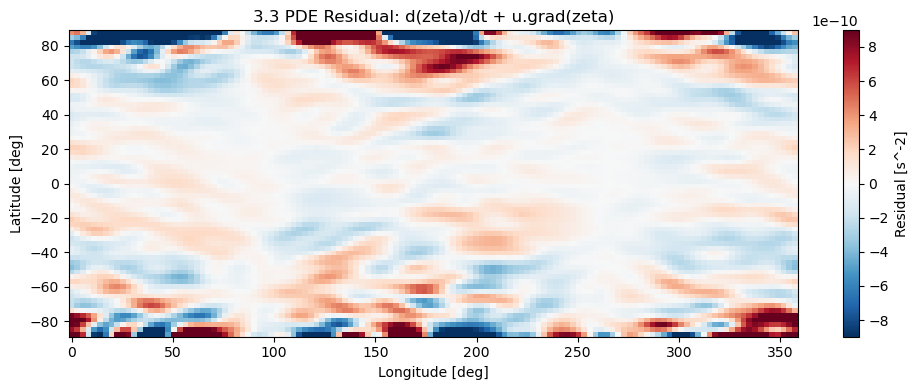

In [12]:
DT = 7.0 * 86400.0

dvdt     = (VOR[1] - VOR[0]) / DT
dvor_dx  = np.gradient(VOR[0], dlon, axis=1) / (EARTH_RADIUS * cos_lat)
dvor_dy  = np.gradient(VOR[0], dlat, axis=0) / EARTH_RADIUS
advection = U_FULL * dvor_dx + V_0 * dvor_dy
residual  = dvdt + advection

fig, ax = plt.subplots(figsize=(10, 4))
vlim = np.percentile(np.abs(residual), 97)
im   = ax.pcolormesh(lon, lat, residual, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto")
fig.colorbar(im, ax=ax, label="Residual [s^-2]")
ax.set_title("3.3 PDE Residual: d(zeta)/dt + u.grad(zeta)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.tight_layout()
plt.show()

---
## Summary

| # | Visualization | Scope | What it shows |
|---|---|---|---|
| 1.1 | Vorticity Evolution | BVE | Spatial structure and propagation over time |
| 1.2 | Streamfunction | BVE | Large-scale circulation, streamlines |
| 1.3 | Zonal Mean U | BVE | Jet structure and its time evolution |
| 1.4 | Hovmoller | BVE | Wave propagation direction and speed |
| 1.5 | Enstrophy | BVE | Conservation diagnostic (small scales) |
| 2.1 | Quiver | Fluids | Velocity field overlaid on scalar field |
| 2.2 | KE Spectrum | Fluids | Energy distribution across scales |
| 2.3 | KE Conservation | Fluids | Conservation diagnostic (large scales) |
| 3.1 | Error Maps | PDE | Spatial error structure (abs/signed/relative) |
| 3.2 | Power Spectrum | PDE | Spectral fidelity of predictions |
| 3.3 | PDE Residual | PDE | Physics consistency of model output |